In [10]:
# =========================
# 0) Colab: Mount Google Drive (R way)
# =========================
system("apt-get -qq install -y google-drive-ocamlfuse > /dev/null")
system("mkdir -p /content/drive")

# Auth popup will appear
system("google-drive-ocamlfuse -headless -id '' -secret '' /content/drive")

# ✅ Save directory
SAVE_DIR <- "/content/drive/MyDrive/Plots/"
dir.create(SAVE_DIR, recursive = TRUE, showWarnings = FALSE)

Warning message in system("google-drive-ocamlfuse -headless -id '' -secret '' /content/drive"):
“error in running command”


In [14]:
library(tidyverse)

# ====== SAVE DIR (set this) ======
# SAVE_DIR <- "/content/drive/MyDrive/Plots/"
# dir.create(SAVE_DIR, recursive = TRUE, showWarnings = FALSE)

# =========================
# Data
# =========================
df <- tibble::tribble(
  ~Model,            ~FileSizeMB, ~LoadTimeMS, ~Throughput, ~CPUMean, ~RAMMeanMB, ~TempMeanC, ~Accuracy, ~MacroPrecision, ~MacroRecall, ~MacroF1,
  "EfficientNetB0",     15.34,        2.8,        3.97,      169.60,    125.74,     72.00,     0.8624,     0.8639,        0.8615,     0.8608,
  "InceptionV3",        83.16,       59.2,        1.04,      289.56,    261.76,     83.36,     0.8730,     0.8732,        0.8720,     0.8690,
  "MobileNetV1",        12.23,        1.3,        7.27,      220.52,    117.15,     75.84,     0.8492,     0.8492,        0.8489,     0.8481,
  "MobileNetV3Small",    3.59,       15.3,       36.56,      166.09,     95.43,     68.60,     0.8228,     0.8195,        0.8195,     0.8194,
  "NASNetMobile",       16.35,        6.2,        4.60,      231.81,    122.92,     75.18,     0.8704,     0.8681,        0.8685,     0.8681,
  "ResNet50",           89.69,       82.4,        1.50,      286.69,    272.50,     83.17,     0.6984,     0.7626,        0.7030,     0.6940
)

# sort models by accuracy
df <- df %>% arrange(desc(Accuracy)) %>% mutate(Model = factor(Model, levels = Model))

# =========================
# ONE style for ALL (make like Graph 3)
# =========================
BAR_W <- 0.22

base_theme <- theme_minimal(base_size = 12) +
  theme(
    legend.position = "top",
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),

    # reduce internal whitespace (side space)
    plot.margin = margin(6, 6, 6, 6),
    panel.spacing = unit(0.12, "lines"),

    strip.text = element_text(face = "bold"),
    strip.background = element_blank(),

    plot.title = element_text(face = "bold", size = 13),
    axis.text.y = element_text(size = 11)
  )

# Reduce x-axis padding like Graph 3
x_tight <- scale_x_continuous(expand = expansion(mult = c(0.01, 0.01)))
y_tight <- scale_y_discrete(expand = expansion(mult = c(0.01, 0.01)))

# Palette (Graph1 needs multiple colors; Graph2/3 can be single)
PAL <- c("Accuracy"="#1f77b4", "Precision"="#ff7f0e", "Recall"="#2ca02c", "F1-score"="#d62728")
BASE_BLUE <- "#1f77b4"

# =========================
# Build long tables (MISSING in your code)
# =========================
g1_long <- df %>%
  select(Model, Accuracy, MacroPrecision, MacroRecall, MacroF1) %>%
  pivot_longer(-Model, names_to = "Metric", values_to = "Value") %>%
  mutate(Metric = recode(Metric,
                         Accuracy="Accuracy",
                         MacroPrecision="Precision",
                         MacroRecall="Recall",
                         MacroF1="F1-score"))

g2_long <- df %>%
  select(Model, CPUMean, RAMMeanMB, TempMeanC) %>%
  pivot_longer(-Model, names_to = "Metric", values_to = "Value") %>%
  mutate(Metric = recode(Metric,
                         CPUMean="CPU Mean (%)",
                         RAMMeanMB="RAM Mean (MB)",
                         TempMeanC="Temp Mean (°C)"))

g3_long <- df %>%
  select(Model, FileSizeMB, LoadTimeMS, Throughput) %>%
  pivot_longer(-Model, names_to = "Metric", values_to = "Value") %>%
  mutate(Metric = recode(Metric,
                         FileSizeMB="File Size (MB)",
                         LoadTimeMS="Load Time Mean (ms)",
                         Throughput="Throughput (img/s)"))

# =========================
# Graph 1: EXACT Graph 3 style but with legend colors
# =========================
p1 <- ggplot(g1_long, aes(x = Value, y = Model, fill = Metric)) +
  geom_col(width = BAR_W, position = position_dodge(width = 0.55)) +
  scale_fill_manual(values = PAL) +
  scale_x_continuous(limits = c(0, 1), expand = expansion(mult = c(0.01, 0.01))) +
  y_tight +
  labs(title = "Classification Metrics (MixedData)", x = NULL, y = NULL) +
  base_theme

ggsave(file.path(SAVE_DIR, "Graph1_Metrics_horizontal.png"),
       p1, width = 11, height = 8, dpi = 300)

# =========================
# Graph 2: EXACT Graph 3 style (same bar width, same tight spacing)
# =========================
p2 <- ggplot(g2_long, aes(x = Value, y = Model)) +
  geom_col(width = BAR_W, fill = BASE_BLUE) +
  facet_wrap(~Metric, scales = "free_x", ncol = 1) +
  x_tight + y_tight +
  labs(title = "Resource Usage (MixedData)", x = NULL, y = NULL) +
  base_theme

ggsave(file.path(SAVE_DIR, "Graph2_Resources_horizontal.png"),
       p2, width = 11, height = 8, dpi = 300)

# =========================
# Graph 3: keep your exact Graph 3 look but tighter padding too
# =========================
p3 <- ggplot(g3_long, aes(x = Value, y = Model)) +
  geom_col(width = BAR_W, fill = BASE_BLUE) +
  facet_wrap(~Metric, scales = "free_x", nrow = 1) +
  x_tight + y_tight +
  labs(title = "Deployment Efficiency (MixedData)", x = NULL, y = NULL) +
  base_theme +
  theme(plot.margin = margin(8, 10, 8, 10))  # a bit more for A4

ggsave(file.path(SAVE_DIR, "Graph3_A4_landscape_fullwidth.png"),
       p3, width = 11.69, height = 8.27, dpi = 300)
ggsave(file.path(SAVE_DIR, "Graph3_A4_landscape_fullwidth.pdf"),
       p3, width = 11.69, height = 8.27)

In [17]:
library(tidyverse)

# ====== Set SAVE_DIR ======
# SAVE_DIR <- "/content/drive/MyDrive/Plots/"
# dir.create(SAVE_DIR, recursive = TRUE, showWarnings = FALSE)

# =========================
# Data
# =========================
df <- tibble::tribble(
  ~Model,            ~FileSizeMB, ~LoadTimeMS, ~Throughput, ~CPUMean, ~RAMMeanMB, ~TempMeanC, ~Accuracy, ~MacroPrecision, ~MacroRecall, ~MacroF1,
  "EfficientNetB0",     15.34,        2.8,        3.97,      169.60,    125.74,     72.00,     0.8624,     0.8639,        0.8615,     0.8608,
  "InceptionV3",        83.16,       59.2,        1.04,      289.56,    261.76,     83.36,     0.8730,     0.8732,        0.8720,     0.8690,
  "MobileNetV1",        12.23,        1.3,        7.27,      220.52,    117.15,     75.84,     0.8492,     0.8492,        0.8489,     0.8481,
  "MobileNetV3Small",    3.59,       15.3,       36.56,      166.09,     95.43,     68.60,     0.8228,     0.8195,        0.8195,     0.8194,
  "NASNetMobile",       16.35,        6.2,        4.60,      231.81,    122.92,     75.18,     0.8704,     0.8681,        0.8685,     0.8681,
  "ResNet50",           89.69,       82.4,        1.50,      286.69,    272.50,     83.17,     0.6984,     0.7626,        0.7030,     0.6940
)

df <- df %>% arrange(desc(Accuracy)) %>% mutate(Model = factor(Model, levels = Model))

# =========================
# Aesthetic colors (consistent + thesis friendly)
# =========================
PAL_METRICS <- c(
  "Accuracy"  = "#2E6FBB",
  "Precision" = "#F39C35",
  "Recall"    = "#2EAD6B",
  "F1-score"  = "#D64541"
)

PAL_RES <- c(
  "CPU Mean (%)"   = "#2E6FBB",
  "RAM Mean (MB)"  = "#F39C35",
  "Temp Mean (°C)" = "#D64541"
)

# =========================
# Common style (reduce whitespace)
# =========================
BAR_W <- 0.22

base_theme <- theme_minimal(base_size = 13) +
  theme(
    legend.position = "top",
    legend.title = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),

    plot.title = element_text(face = "bold", size = 14),

    # reduce inner whitespace
    plot.margin = margin(6, 6, 6, 6),
    panel.spacing = unit(0.10, "lines"),

    axis.title.x = element_text(margin = margin(t = 4)),
    axis.text.y  = element_text(size = 11),

    strip.text = element_text(face = "bold"),
    strip.background = element_blank()
  )

x_tight <- function() scale_x_continuous(expand = expansion(mult = c(0.01, 0.01)))
y_tight <- function() scale_y_discrete(expand = expansion(mult = c(0.01, 0.01)))

# =========================
# Long tables
# =========================
g1_long <- df %>%
  select(Model, Accuracy, MacroPrecision, MacroRecall, MacroF1) %>%
  pivot_longer(-Model, names_to = "Metric", values_to = "Value") %>%
  mutate(Metric = recode(Metric,
                         Accuracy="Accuracy",
                         MacroPrecision="Precision",
                         MacroRecall="Recall",
                         MacroF1="F1-score"))

g2_long <- df %>%
  select(Model, CPUMean, RAMMeanMB, TempMeanC) %>%
  pivot_longer(-Model, names_to = "Metric", values_to = "Value") %>%
  mutate(Metric = recode(Metric,
                         CPUMean="CPU Mean (%)",
                         RAMMeanMB="RAM Mean (MB)",
                         TempMeanC="Temp Mean (°C)"))

g3_long <- df %>%
  select(Model, FileSizeMB, LoadTimeMS, Throughput) %>%
  pivot_longer(-Model, names_to = "Metric", values_to = "Value") %>%
  mutate(Metric = recode(Metric,
                         FileSizeMB="File Size (MB)",
                         LoadTimeMS="Load Time Mean (ms)",
                         Throughput="Throughput (img/s)"))

# =========================
# Graph 1 (1.5:1)
# =========================
p1 <- ggplot(g1_long, aes(x = Value, y = Model, fill = Metric)) +
  geom_col(width = BAR_W, position = position_dodge(width = 0.55)) +
  scale_fill_manual(values = PAL_METRICS) +
  scale_x_continuous(limits = c(0, 1), expand = expansion(mult = c(0.01, 0.01))) +
  y_tight() +
  labs(title = "Classification Metrics (MixedData)", x = NULL, y = NULL) +
  base_theme

# 1.5:1 example: 12 x 8 inches => 1.5
ggsave(file.path(SAVE_DIR, "Graph1_Metrics_1p5x1.png"),
       p1, width = 12, height = 8, dpi = 300)

# =========================
# Graph 2 (1.5:1) - SAME style as Graph 1 + 3 colors (CPU/RAM/Temp)
# =========================
p2 <- ggplot(g2_long, aes(x = Value, y = Model, fill = Metric)) +
  geom_col(width = BAR_W, position = position_dodge(width = 0.55)) +
  scale_fill_manual(values = PAL_RES) +
  x_tight() + y_tight() +
  facet_wrap(~Metric, scales = "free_x", ncol = 1) +
  labs(title = "Resource Usage (MixedData)", x = NULL, y = NULL) +
  base_theme

ggsave(file.path(SAVE_DIR, "Graph2_Resources_1p5x1.png"),
       p2, width = 12, height = 8, dpi = 300)

# =========================
# Graph 3 (3:1) - 3300x1100 px style
# =========================
p3 <- ggplot(g3_long, aes(x = Value, y = Model, fill = Metric)) +
  geom_col(width = BAR_W) +
  facet_wrap(~Metric, scales = "free_x", nrow = 1) +
  scale_fill_manual(values = c(
    "File Size (MB)" = "#2E6FBB",
    "Load Time Mean (ms)" = "#F39C35",
    "Throughput (img/s)" = "#2EAD6B"
  )) +
  x_tight() + y_tight() +
  labs(title = "Deployment Efficiency (MixedData)", x = NULL, y = NULL) +
  base_theme +
  theme(legend.position = "none")  # clean for wide banner

# 3:1 => width 11 inches, height 3.666.. inches (11/3 = 3.0)
ggsave(file.path(SAVE_DIR, "Graph3_Efficiency_3x1.png"),
       p3, width = 11, height = 11/3, dpi = 300)

# Exactly 3300x1100 pixels version (same 3:1)
ggsave(file.path(SAVE_DIR, "Graph3_Efficiency_3300x1100.png"),
       p3, width = 3300/300, height = 1100/300, dpi = 300)

# Optional PDF (vector)
ggsave(file.path(SAVE_DIR, "Graph3_Efficiency_3x1.pdf"),
       p3, width = 11, height = 11/3)

# A tibble: 24 × 3
   Model          Metric    Value
   <fct>          <chr>     <dbl>
 1 ResNet50       Accuracy  0.957
 2 ResNet50       Precision 0.958
 3 ResNet50       Recall    0.957
 4 ResNet50       F1-score  0.957
 5 EfficientNetB0 Accuracy  0.955
 6 EfficientNetB0 Precision 0.955
 7 EfficientNetB0 Recall    0.955
 8 EfficientNetB0 F1-score  0.955
 9 InceptionV3    Accuracy  0.952
10 InceptionV3    Precision 0.953
# ℹ 14 more rows
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.9339  0.9424  0.9480  0.9474  0.9548  0.9576 


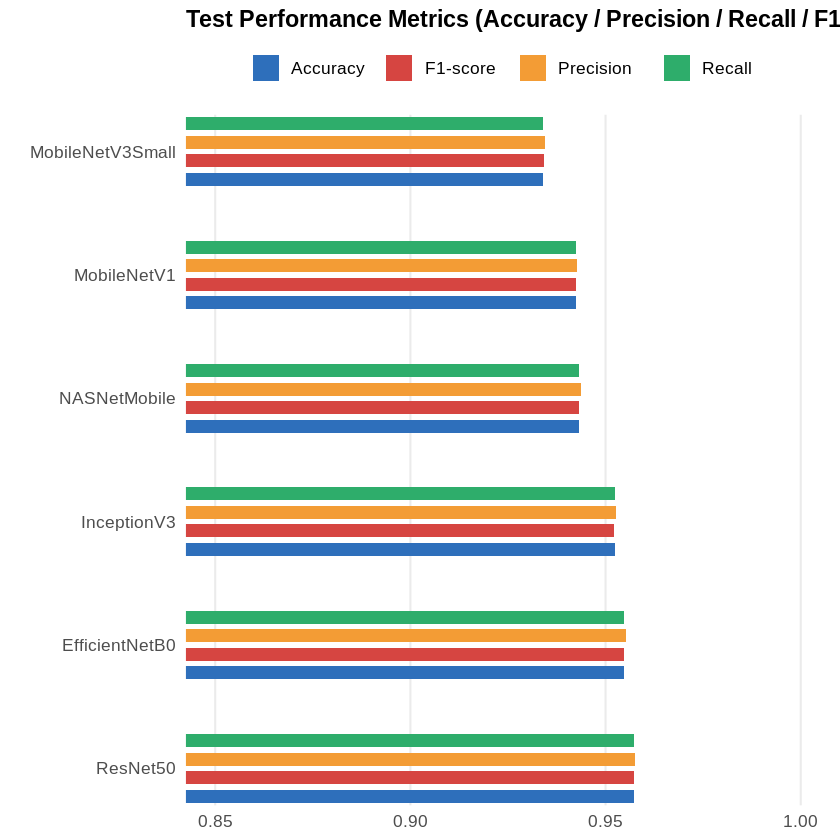

In [25]:
library(tidyverse)

# =========================
# SAVE DIRECTORY (set this)
# =========================
# Example (Colab after python drive.mount):
# SAVE_DIR <- "/content/drive/MyDrive/Plots/"
# dir.create(SAVE_DIR, recursive = TRUE, showWarnings = FALSE)

# If you don't want Drive, use current folder:
if (!exists("SAVE_DIR")) {
  SAVE_DIR <- "."
}

# =========================
# Data
# =========================
df2 <- tribble(
  ~Model, ~CV_Accuracy_Mean, ~CV_Accuracy_std, ~Test_Accuracy, ~Precision, ~Recall, ~F1_Score, ~Parameters, ~Model_Size_MB, ~Throughput,
  "EfficientNetB0",   0.9394, 0.0087, 0.9548, 0.9552, 0.9548, 0.9548, 4054695, 16.26, 176.23,
  "InceptionV3",      0.9520, 0.0065, 0.9523, 0.9527, 0.9523, 0.9522, 21810980, 84.24, 6.21,
  "MobileNetV1",      0.9222, 0.0099, 0.9423, 0.9427, 0.9423, 0.9424, 3232964, 12.64, 212.03,
  "MobileNetV3Small", 0.9168, 0.0044, 0.9339, 0.9344, 0.9339, 0.9341, 941428,  4.13, 323.93,
  "NASNetMobile",     0.9419, 0.0015, 0.9431, 0.9438, 0.9431, 0.9433, 4273944, 18.89, 14.08,
  "ResNet50",         0.9448, 0.0045, 0.9574, 0.9576, 0.9574, 0.9573, 23595908, 90.63, 4.69
)

# Sort models
df2 <- df2 %>%
  arrange(desc(Test_Accuracy)) %>%
  mutate(Model = factor(Model, levels = Model))

# =========================
# Long format (FORCE numeric)
# =========================
m_long <- df2 %>%
  select(Model, Test_Accuracy, Precision, Recall, F1_Score) %>%
  pivot_longer(-Model, names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric = recode(Metric,
                    Test_Accuracy = "Accuracy",
                    Precision     = "Precision",
                    Recall        = "Recall",
                    F1_Score      = "F1-score"),
    # ✅ critical: ensure numeric even if something became character
    Value = as.numeric(Value)
  )

# quick sanity check (optional)
print(m_long)
print(summary(m_long$Value))

# =========================
# Colors + Theme
# =========================
PAL <- c(
  "Accuracy"  = "#2E6FBB",
  "Precision" = "#F39C35",
  "Recall"    = "#2EAD6B",
  "F1-score"  = "#D64541"
)

BAR_W <- 0.42

base_theme <- theme_minimal(base_size = 13) +
  theme(
    legend.position = "top",
    legend.title = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(face = "bold", size = 14),
    plot.margin = margin(6, 6, 6, 6)
  )

# =========================
# Plot (use coord_cartesian for zoom without dropping)
# =========================
p <- ggplot(m_long, aes(x = Value, y = Model, fill = Metric)) +
  geom_col(width = BAR_W, position = position_dodge(width = 0.60)) +
  scale_fill_manual(values = PAL) +
  scale_y_discrete(expand = expansion(mult = c(0.06, 0.06))) +
  coord_cartesian(xlim = c(0.85, 1.00)) +  # ✅ zoom without dropping data
  labs(
    title = "Test Performance Metrics (Accuracy / Precision / Recall / F1)",
    x = NULL, y = NULL
  ) +
  base_theme

# Show in notebook
print(p)

# =========================
# Save 3:1 exact 3300x1100
# =========================
ggsave(
  filename = file.path(SAVE_DIR, "Metrics_3x1_3300x1100.png"),
  plot = p,
  width = 3300/300,
  height = 1800/300,
  dpi = 300,
  bg = "white"
)

ggsave(
  filename = file.path(SAVE_DIR, "Metrics_3x1.pdf"),
  plot = p,
  width = 11,
  height = 11/3
)